In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from tifffile import imread
from scipy import ndimage as ndi
from scipy.interpolate import interp1d


def get_midplane(img):
    """
    Return the midplane of a 3D image.
    Assumes image shape is (z, y, x).
    If image is already 2D, returns it unchanged.
    """
    if img.ndim == 2:
        return img
    elif img.ndim == 3:
        mid = img.shape[0] // 2
        return img[mid]
    else:
        raise ValueError(f"Expected 2D or 3D image, got shape {img.shape}")


def extract_radial_rings_from_masked_image(midplane, connectivity=1):
    """
    Given a 2D masked intensity image where background is 0,
    iteratively find boundary rings moving inward.

    Returns
    -------
    ring_means : list of float
        Mean intensity of each successive inward ring.
    ring_masks : list of ndarray[bool]
        Optional debug output: the mask for each ring.
    """
    if midplane.ndim != 2:
        raise ValueError("midplane must be 2D")

    # Foreground mask: all nonzero pixels
    mask = midplane > 0

    if not np.any(mask):
        return [], []

    structure = ndi.generate_binary_structure(2, connectivity)

    working_mask = mask.copy()
    ring_means = []
    ring_masks = []

    while np.any(working_mask):
        # Erode once
        eroded = ndi.binary_erosion(working_mask, structure=structure, border_value=0)

        # Boundary ring = current mask minus eroded interior
        ring = working_mask & (~eroded)

        if not np.any(ring):
            break

        ring_values = midplane[ring]

        # ring is inside mask, but keep a safeguard
        ring_values = ring_values[ring_values > 0]

        if ring_values.size == 0:
            ring_means.append(np.nan)
        else:
            ring_means.append(np.mean(ring_values))

        ring_masks.append(ring)
        working_mask = eroded

    return ring_means, ring_masks


def interpolate_profile(profile, n_points=20):
    """
    Interpolate a 1D profile to exactly n_points.

    If the profile has:
    - 0 points: returns all NaN
    - 1 point: repeats that value
    - >=2 points: linear interpolation
    """
    profile = np.asarray(profile, dtype=float)

    if len(profile) == 0:
        return np.full(n_points, np.nan, dtype=float)

    if len(profile) == 1:
        return np.full(n_points, profile[0], dtype=float)

    x_old = np.linspace(0, 1, len(profile))
    x_new = np.linspace(0, 1, n_points)

    f = interp1d(x_old, profile, kind="linear")
    return f(x_new)


def process_single_image(image_path, n_points=20, connectivity=1):
    """
    Process one image file:
    - load image
    - get midplane
    - extract inward radial ring means
    - interpolate to fixed length

    Returns a dict suitable for DataFrame construction.
    """
    img = imread(str(image_path)).astype(float)
    
    # Min-max normalize the whole image to 0-1
    img_min = np.min(img)
    img_max = np.max(img)
    
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
    else:
        img = np.zeros_like(img, dtype=float)
    
    midplane = get_midplane(img)
    ring_means, _ = extract_radial_rings_from_masked_image(midplane, connectivity=connectivity)
    interp_profile = interpolate_profile(ring_means, n_points=n_points)

    result = {
        "file": image_path.name,
        "n_rings_original": len(ring_means),
    }

    for i, val in enumerate(interp_profile):
        result[f"profile_{i+1:02d}"] = val

    return result

def process_single_image_twochannel(image_path, n_points=20, connectivity=1):
    img = imread(str(image_path)).astype(float)

    # Split channels
    ch1_img, ch2_img = split_two_channel_image(img)

    # Midplane for each channel
    ch1_mid = get_midplane(ch1_img)
    ch2_mid = get_midplane(ch2_img)

    # Radial profiles for each channel
    ch1_ring_means, _ = extract_radial_rings_from_masked_image(ch1_mid, connectivity=connectivity)
    ch2_ring_means, _ = extract_radial_rings_from_masked_image(ch2_mid, connectivity=connectivity)

    # Interpolate to fixed length
    ch1_profile = interpolate_profile(ch1_ring_means, n_points=n_points)
    ch2_profile = interpolate_profile(ch2_ring_means, n_points=n_points)

    result = {
        "file": image_path.name,
        "ch1_n_rings_original": len(ch1_ring_means),
        "ch2_n_rings_original": len(ch2_ring_means),
    }

    for i, val in enumerate(ch1_profile):
        result[f"ch1_profile_{i+1:02d}"] = val

    for i, val in enumerate(ch2_profile):
        result[f"ch2_profile_{i+1:02d}"] = val

    return result

def split_two_channel_image(img):
    """
    Find the axis with length 2 and split the image into two channel images.

    Returns
    -------
    ch1, ch2 : ndarray
        Arrays with the channel axis removed.
    """
    channel_axes = [i for i, s in enumerate(img.shape) if s == 2]

    if len(channel_axes) == 0:
        raise ValueError(f"No axis of length 2 found in image shape {img.shape}")
    if len(channel_axes) > 1:
        raise ValueError(f"Multiple axes of length 2 found in image shape {img.shape}; ambiguous channel axis")

    ch_axis = channel_axes[0]

    ch1 = np.take(img, indices=0, axis=ch_axis)
    ch2 = np.take(img, indices=1, axis=ch_axis)
    # print(ch1.shape)
    # print(ch2.shape)
    return ch1, ch2


def process_directory(
    input_dir,
    output_csv=None,
    glob_patterns=("*.tif", "*.tiff"),
    n_points=20,
    connectivity=1,
    multichannel=False
):
    """
    Iterate through a directory of images and extract 20-point radial profiles.

    Parameters
    ----------
    input_dir : str or Path
        Directory containing images.
    output_csv : str or Path or None
        If provided, save the results to CSV.
    glob_patterns : tuple of str
        File patterns to search for.
    n_points : int
        Number of interpolated profile points.
    connectivity : int
        Connectivity for boundary finding:
        1 = 4-connectivity
        2 = 8-connectivity

    Returns
    -------
    df : pandas.DataFrame
        One row per image, with columns profile_01 ... profile_20
    """
    input_dir = Path(input_dir)

    image_paths = []
    for pattern in glob_patterns:
        image_paths.extend(input_dir.glob(pattern))

    image_paths = sorted(image_paths)

    if len(image_paths) == 0:
        raise FileNotFoundError(f"No image files found in {input_dir}")

    results = []
    for path in image_paths:
        if multichannel:
            try:
                res = process_single_image_twochannel(path, n_points=n_points, connectivity=connectivity)
                results.append(res)
            except Exception as e:
                results.append({
                    "file": path.name,
                    "ch1_n_rings_original": np.nan,
                    "ch2_n_rings_original": np.nan,
                    **{f"ch1_profile_{i+1:02d}": np.nan for i in range(n_points)},
                    **{f"ch2_profile_{i+1:02d}": np.nan for i in range(n_points)},
                    "error": str(e)
                })
        else:
            try:
                res = process_single_image(path, n_points=n_points, connectivity=connectivity)
                results.append(res)
            except Exception as e:
                results.append({
                    "file": path.name,
                    "n_rings_original": np.nan,
                    **{f"profile_{i+1:02d}": np.nan for i in range(n_points)},
                    "error": str(e)
                })

    df = pd.DataFrame(results)

    if output_csv is not None:
        df.to_csv(output_csv, index=False)

    return df

In [8]:
if __name__ == "__main__":
    input_dir = '''Directory containing segmented/normalized Lamp1/Lamp3 image volume data'''
    output_csv = '''Output directory for csv, to be read back in at a subsequent step'''

    df = process_directory(
        input_dir=input_dir,
        output_csv=output_csv,
        n_points=20,
        connectivity=1,  # try 2 if you want diagonal connectivity included
        multichannel=True
    )

FileNotFoundError: No image files found in Directory containing segmented/normalized Lamp1/Lamp3 image volume data

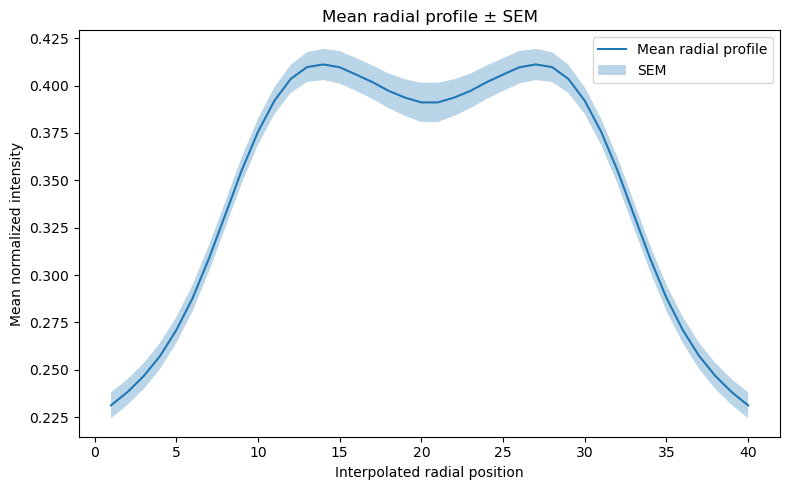

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# USER INPUT
# =========================
csv_path = output_csv

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(csv_path)

channel = 'ch1' #Manually select if you want to look at Lamp1 (ch1) or Lamp3 (ch2)

profile_cols = [col for col in df.columns if col.startswith(f"{channel}_profile_")]
profile_cols = sorted(profile_cols)

if len(profile_cols) == 0:
    raise ValueError("No profile columns found in the CSV.")

# Extract original 20-point profiles
profile_data = df[profile_cols].to_numpy(dtype=float)

# Mirror each row to create a 40-point profile
# This makes: [p1, p2, ..., p20, p20, p19, ..., p1]
mirrored_profile_data = np.concatenate(
    [profile_data, profile_data[:, ::-1]],
    axis=1
)

# Optional: put back into a dataframe
mirrored_cols = [f"profile_{i+1:02d}" for i in range(mirrored_profile_data.shape[1])]
df_profiles = pd.DataFrame(mirrored_profile_data, columns=mirrored_cols)



# Keep only the interpolated profile columns
profile_cols = [col for col in df.columns if col.startswith(f"{channel}_profile_")]
profile_cols = sorted(profile_cols)

if len(profile_cols) == 0:
    raise ValueError("No profile columns found in the CSV.")

profile_data = df[profile_cols].to_numpy(dtype=float)

# =========================
# CALCULATE MEAN AND SEM
# =========================
mean_profile = np.nanmean(mirrored_profile_data, axis=0)

n = np.sum(~np.isnan(mirrored_profile_data), axis=0)
std_profile = np.nanstd(mirrored_profile_data, axis=0, ddof=1)
sem_profile = std_profile / np.sqrt(n)

x = np.arange(1, mirrored_profile_data.shape[1] + 1)

# =========================
# PLOT
# =========================
plt.figure(figsize=(8, 5))
plt.plot(x, mean_profile, label="Mean radial profile")
plt.fill_between(
    x,
    mean_profile - sem_profile,
    mean_profile + sem_profile,
    alpha=0.3,
    label="SEM"
)

plt.xlabel("Interpolated radial position")
plt.ylabel("Mean normalized intensity")
plt.title("Mean radial profile ± SEM")
plt.legend()
plt.tight_layout()
plt.show()